## Regression Model to predict the amount of Co2 carbon emissions saved by user based on daily tasks

In [1]:
import pandas as pd
import numpy as np
import sklearn
print(sklearn.__version__)
import matplotlib.pyplot as plt
import seaborn as sns

1.8.0


## data exploration (EDA)

In [ ]:
df = pd.read_csv('co2_dataset_factual.csv')

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
features_to_keep = [
    'plastic_bottles_recycled',
    'aluminum_cans_recycled',
    'paper_recycled_kg',
    'cardboard_recycled_kg',
    'glass_bottles_recycled',
    'reusable_bags_used',
    'reusable_water_bottle_uses',
    'miles_biked',
    'miles_walked',
    'miles_public_transit',
    'miles_carpooled',
    'led_bulb_hours'
]

CO2_FACTORS_FILTERED = {
    'plastic_bottles_recycled': 0.082,
    'aluminum_cans_recycled': 0.166,
    'paper_recycled_kg': 0.9,
    'cardboard_recycled_kg': 0.75,
    'glass_bottles_recycled': 0.15,
    'reusable_bags_used': 0.04,
    'reusable_water_bottle_uses': 0.082,
    'miles_biked': 0.411,
    'miles_walked': 0.411,
    'miles_public_transit': 0.255,
    'miles_carpooled': 0.206,
    'led_bulb_hours': 0.045
}


df['co2_saved_kg'] = 0  # Reset to 0

for feature, factor in CO2_FACTORS_FILTERED.items():
    df['co2_saved_kg'] += df[feature] * factor

# Round it
df['co2_saved_kg'] = df['co2_saved_kg'].round(2)

# NOW drop the unwanted columns
columns_to_drop = ['vegetarian_meals', 'vegan_meals', 'local_food_kg', 
                   'cold_water_laundry_loads', 'line_dried_loads', 'composting_kg']
df = df.drop(columns=columns_to_drop)

# Save the corrected dataset
df.to_csv('co2_dataset_corrected.csv', index=False)

## check for missing values before training data 

In [8]:
new_df = pd.read_csv('co2_dataset_corrected.csv')

In [9]:
new_df.columns

Index(['plastic_bottles_recycled', 'aluminum_cans_recycled',
       'paper_recycled_kg', 'cardboard_recycled_kg', 'glass_bottles_recycled',
       'reusable_bags_used', 'reusable_water_bottle_uses', 'miles_biked',
       'miles_walked', 'miles_public_transit', 'miles_carpooled',
       'led_bulb_hours', 'co2_saved_kg'],
      dtype='object')

In [10]:
##check for missing values
print("\nMissing Values:")
print(new_df.isnull().sum())
print(f"\nTotal missing: {new_df.isnull().sum().sum()}")



Missing Values:
plastic_bottles_recycled      0
aluminum_cans_recycled        0
paper_recycled_kg             0
cardboard_recycled_kg         0
glass_bottles_recycled        0
reusable_bags_used            0
reusable_water_bottle_uses    0
miles_biked                   0
miles_walked                  0
miles_public_transit          0
miles_carpooled               0
led_bulb_hours                0
co2_saved_kg                  0
dtype: int64

Total missing: 0


In [11]:
## corelation analysis 
correlation = new_df.corr()['co2_saved_kg'].sort_values(ascending=False)
print("\nCorrelation with CO2 Saved:")
print(correlation)


Correlation with CO2 Saved:
co2_saved_kg                  1.000000
miles_public_transit          0.586011
miles_biked                   0.531605
miles_walked                  0.339844
paper_recycled_kg             0.314440
miles_carpooled               0.313052
cardboard_recycled_kg         0.189273
aluminum_cans_recycled        0.123577
led_bulb_hours                0.068944
glass_bottles_recycled        0.058666
plastic_bottles_recycled      0.056651
reusable_water_bottle_uses    0.040192
reusable_bags_used            0.039925
Name: co2_saved_kg, dtype: float64


In [13]:
contributions = {}
for col in new_df.columns:
    if col != 'co2_saved_kg':
        # Calculate what % of total CO2 this feature contributes on average
        contributions[col] = new_df[col].mean()

contributions_df = pd.DataFrame(list(contributions.items()), 
                                columns=['Feature', 'Avg_Value'])
contributions_df = contributions_df.sort_values('Avg_Value', ascending=False)
print("\nAverage Values per Feature (before dropping):")
print(contributions_df)


Average Values per Feature (before dropping):
                       Feature  Avg_Value
11              led_bulb_hours   11.94819
9         miles_public_transit   10.03361
10             miles_carpooled    7.46836
7                  miles_biked    6.07742
0     plastic_bottles_recycled    3.58100
8                 miles_walked    2.51178
6   reusable_water_bottle_uses    2.45700
5           reusable_bags_used    1.99500
1       aluminum_cans_recycled    1.95200
4       glass_bottles_recycled    1.50000
2            paper_recycled_kg    1.49371
3        cardboard_recycled_kg    0.99771


## Model Training

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

In [17]:
## prepare features for model training
# Features (X) = all columns except co2_saved_kg
# Target (y) = co2_saved_kg
X = new_df.drop('co2_saved_kg', axis=1)
y = new_df['co2_saved_kg']


In [18]:
feature_names = X.columns.tolist()

print(f"\n Features ({len(feature_names)}):")
for i, feature in enumerate(feature_names, 1):
    print(f"  {i}. {feature}")

print(f"\n Target: co2_saved_kg")


 Features (12):
  1. plastic_bottles_recycled
  2. aluminum_cans_recycled
  3. paper_recycled_kg
  4. cardboard_recycled_kg
  5. glass_bottles_recycled
  6. reusable_bags_used
  7. reusable_water_bottle_uses
  8. miles_biked
  9. miles_walked
  10. miles_public_transit
  11. miles_carpooled
  12. led_bulb_hours

 Target: co2_saved_kg


In [19]:
## Train test split - split data into trainign and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results = {}

In [21]:
for name, model in models.items():
    print(f"\n Training {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    # Store results
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'predictions': y_pred_test
    }
    
    print(f"  ✓ Train R²: {train_r2:.4f}")
    print(f"  ✓ Test R²: {test_r2:.4f}")
    print(f"  ✓ RMSE: {test_rmse:.4f} kg")
    print(f"  ✓ MAE: {test_mae:.4f} kg")


 Training Linear Regression...
  ✓ Train R²: 1.0000
  ✓ Test R²: 1.0000
  ✓ RMSE: 0.0029 kg
  ✓ MAE: 0.0025 kg

 Training Ridge Regression...
  ✓ Train R²: 1.0000
  ✓ Test R²: 1.0000
  ✓ RMSE: 0.0040 kg
  ✓ MAE: 0.0033 kg

 Training Lasso Regression...
  ✓ Train R²: 0.9886
  ✓ Test R²: 0.9872
  ✓ RMSE: 0.2952 kg
  ✓ MAE: 0.2400 kg

 Training Decision Tree...
  ✓ Train R²: 0.9956
  ✓ Test R²: 0.7000
  ✓ RMSE: 1.4315 kg
  ✓ MAE: 1.1561 kg

 Training Random Forest...
  ✓ Train R²: 0.9818
  ✓ Test R²: 0.8810
  ✓ RMSE: 0.9017 kg
  ✓ MAE: 0.7003 kg

 Training Gradient Boosting...
  ✓ Train R²: 0.9991
  ✓ Test R²: 0.9280
  ✓ RMSE: 0.7011 kg
  ✓ MAE: 0.5591 kg


In [23]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'Train R²': [results[m]['train_r2'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'RMSE (kg)': [results[m]['test_rmse'] for m in results.keys()],
    'MAE (kg)': [results[m]['test_mae'] for m in results.keys()]
})


MODEL COMPARISON


In [24]:
comparison_df = comparison_df.sort_values('Test R²', ascending=False)
print(comparison_df.to_string(index=False))

            Model  Train R²  Test R²  RMSE (kg)  MAE (kg)
Linear Regression  0.999999 0.999999   0.002932  0.002535
 Ridge Regression  0.999998 0.999998   0.003957  0.003272
 Lasso Regression  0.988565 0.987239   0.295212  0.240030
Gradient Boosting  0.999056 0.928017   0.701140  0.559144
    Random Forest  0.981765 0.880958   0.901652  0.700277
    Decision Tree  0.995567 0.699960   1.431458  1.156100


In [ ]:
## model results analysis
## - Linear Regression - nearly perfect predictions
## - Ridge Regression - also nearly perfect predictions
## - Lasso Regression - nearly perfect but slightly less accurate
## - decision tree - overfitting (good on training data but bad on test)
## - random forest - 92.8% really good
## gradient boosting - similar to RF

In [25]:
# Best model
best_model_name = max(results, key=lambda x: results[x]['test_r2'])
best_model = results[best_model_name]['model']

print("\n" + "="*70)
print(f" BEST MODEL: {best_model_name}")
print("="*70)
print(f"Test R² Score: {results[best_model_name]['test_r2']:.4f} ({results[best_model_name]['test_r2']*100:.2f}% accuracy)")
print(f"RMSE: {results[best_model_name]['test_rmse']:.4f} kg CO2")
print(f"MAE: {results[best_model_name]['test_mae']:.4f} kg CO2")



 BEST MODEL: Linear Regression
Test R² Score: 1.0000 (100.00% accuracy)
RMSE: 0.0029 kg CO2
MAE: 0.0025 kg CO2


In [ ]:
## we should choose linear regression model because it is the best choice for our case since the our dataset prediction 
## is a simple linear equation 


✓ Prediction plot saved as 'predictions_vs_actual.png'


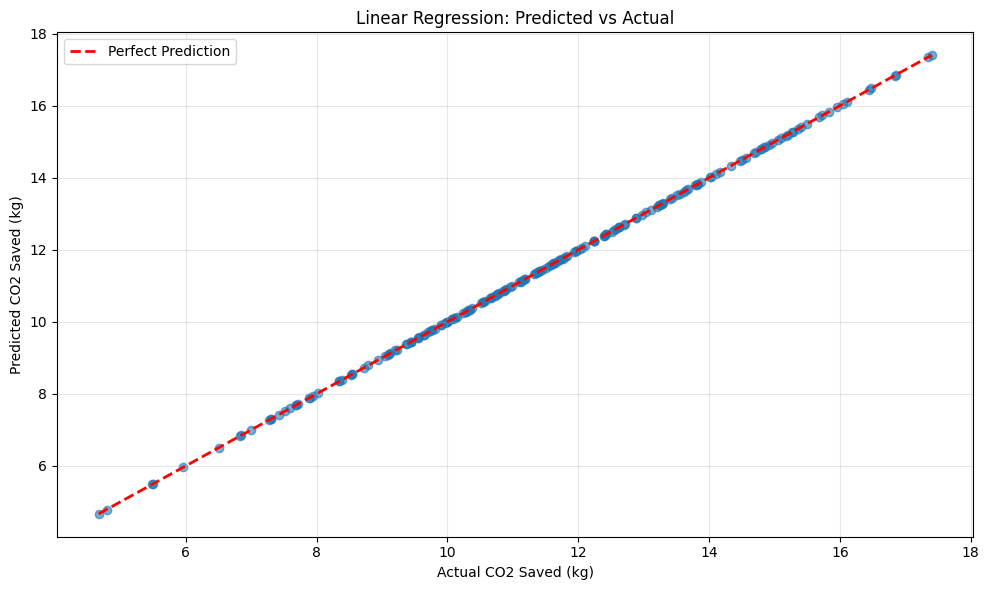

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, results[best_model_name]['predictions'], alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual CO2 Saved (kg)')
plt.ylabel('Predicted CO2 Saved (kg)')
plt.title(f'{best_model_name}: Predicted vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=300, bbox_inches='tight')
print("\n✓ Prediction plot saved as 'predictions_vs_actual.png'")

In [27]:
# Best model
best_model_name = max(results, key=lambda x: results[x]['test_r2'])
best_model = results[best_model_name]['model']

print("\n" + "="*70)
print(f"🏆 BEST MODEL: {best_model_name}")
print("="*70)
print(f"Test R² Score: {results[best_model_name]['test_r2']:.4f} ({results[best_model_name]['test_r2']*100:.2f}% accuracy)")
print(f"RMSE: {results[best_model_name]['test_rmse']:.4f} kg CO2")
print(f"MAE: {results[best_model_name]['test_mae']:.4f} kg CO2")


🏆 BEST MODEL: Linear Regression
Test R² Score: 1.0000 (100.00% accuracy)
RMSE: 0.0029 kg CO2
MAE: 0.0025 kg CO2


In [28]:
joblib.dump(best_model, 'co2_prediction_model.pkl')
print(f"\n✓ Best model saved as 'co2_prediction_model.pkl'")


✓ Best model saved as 'co2_prediction_model.pkl'



FEATURE COEFFICIENTS

 Feature Coefficients:
  paper_recycled_kg: 0.8998
  cardboard_recycled_kg: 0.7500
  miles_biked: 0.4110
  miles_walked: 0.4109
  miles_public_transit: 0.2550
  miles_carpooled: 0.2060
  aluminum_cans_recycled: 0.1660
  glass_bottles_recycled: 0.1498
  plastic_bottles_recycled: 0.0820
  reusable_water_bottle_uses: 0.0820
  led_bulb_hours: 0.0450
  reusable_bags_used: 0.0399

✓ Feature coefficients plot saved as 'feature_coefficients.png'

✓ Prediction plot saved as 'predictions_vs_actual.png'

✓ Best model saved as 'co2_prediction_model.pkl'
✓ Feature names saved as 'feature_names.pkl'

EXAMPLE PREDICTION

 Example Daily Actions:
  • Plastic Bottles Recycled: 5
  • Aluminum Cans Recycled: 3
  • Paper Recycled Kg: 1.0
  • Cardboard Recycled Kg: 0.5
  • Glass Bottles Recycled: 2
  • Reusable Bags Used: 3
  • Reusable Water Bottle Uses: 4
  • Miles Biked: 5.0
  • Miles Walked: 2.0
  • Miles Public Transit: 8.0
  • Led Bulb Hours: 10.0

 Predicted CO2 Saved: 8.30 kg


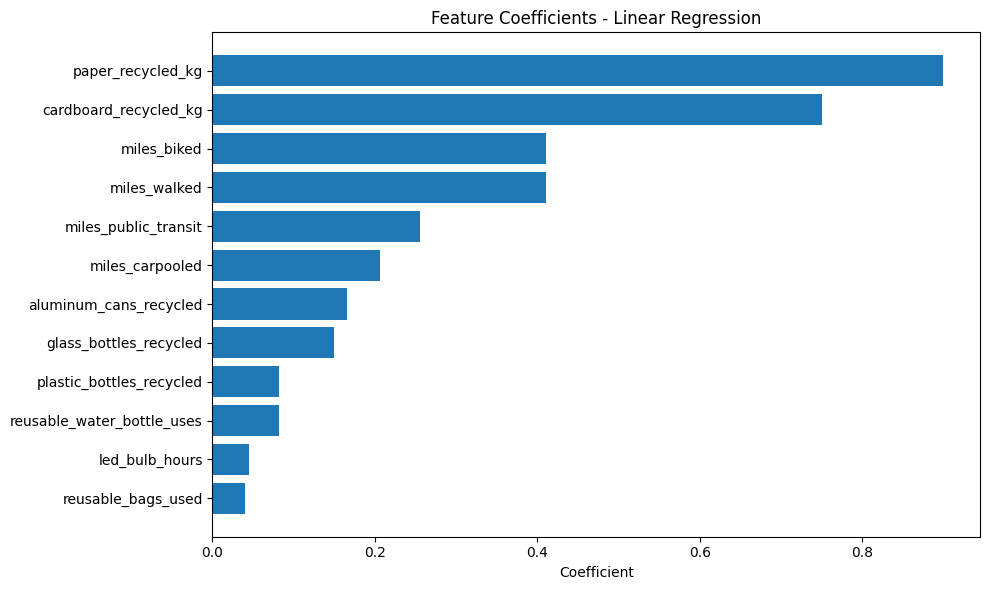

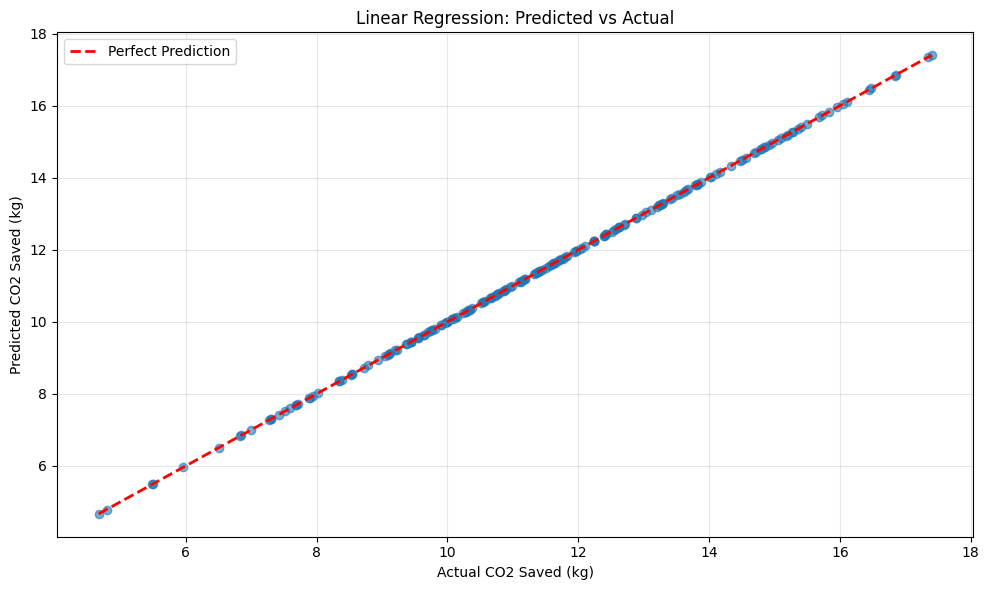

In [33]:
if hasattr(best_model, 'feature_importances_'):
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE")
    print("="*70)
    
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n Top Features:")
    for idx, row in feature_importance.iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    print("\n✓ Feature importance plot saved as 'feature_importance.png'")

elif hasattr(best_model, 'coef_'):
    print("\n" + "="*70)
    print("FEATURE COEFFICIENTS")
    print("="*70)
    
    coefficients = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', ascending=False)
    
    print("\n Feature Coefficients:")
    for idx, row in coefficients.iterrows():
        print(f"  {row['Feature']}: {row['Coefficient']:.4f}")
    
    # Plot coefficients
    plt.figure(figsize=(10, 6))
    plt.barh(coefficients['Feature'], coefficients['Coefficient'])
    plt.xlabel('Coefficient')
    plt.title(f'Feature Coefficients - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_coefficients.png', dpi=300, bbox_inches='tight')
    print("\n✓ Feature coefficients plot saved as 'feature_coefficients.png'")

# =============================================================================
# 7. VISUALIZE PREDICTIONS
# =============================================================================
plt.figure(figsize=(10, 6))
plt.scatter(y_test, results[best_model_name]['predictions'], alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual CO2 Saved (kg)')
plt.ylabel('Predicted CO2 Saved (kg)')
plt.title(f'{best_model_name}: Predicted vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=300, bbox_inches='tight')
print("\n✓ Prediction plot saved as 'predictions_vs_actual.png'")

# =============================================================================
# 8. SAVE THE MODEL
# =============================================================================
joblib.dump(best_model, 'co2_prediction_model.pkl')
print(f"\n✓ Best model saved as 'co2_prediction_model.pkl'")

# Save feature names for later use
joblib.dump(feature_names, 'feature_names.pkl')
print("✓ Feature names saved as 'feature_names.pkl'")

# =============================================================================
# 9. EXAMPLE PREDICTION
# =============================================================================
print("\n" + "="*70)
print("EXAMPLE PREDICTION")
print("="*70)

# Example: User recycles 5 bottles, bikes 3 miles, uses 2 reusable bags
example_input = {
    'plastic_bottles_recycled': 5,
    'aluminum_cans_recycled': 3,
    'paper_recycled_kg': 1.0,
    'cardboard_recycled_kg': 0.5,
    'glass_bottles_recycled': 2,
    'reusable_bags_used': 3,
    'reusable_water_bottle_uses': 4,
    'miles_biked': 5.0,
    'miles_walked': 2.0,
    'miles_public_transit': 8.0,
    'miles_carpooled': 0,
    'led_bulb_hours': 10.0
}

# Create DataFrame with same column order as training
example_df = pd.DataFrame([example_input])[feature_names]
predicted_co2 = best_model.predict(example_df)[0]

print("\n Example Daily Actions:")
for action, value in example_input.items():
    if value > 0:
        print(f"  • {action.replace('_', ' ').title()}: {value}")

print(f"\n Predicted CO2 Saved: {predicted_co2:.2f} kg")
print(f" Weekly Impact: {predicted_co2 * 7:.2f} kg")
print(f" Monthly Impact: {predicted_co2 * 30:.2f} kg")
print(f" Yearly Impact: {predicted_co2 * 365:.2f} kg")
print(f" Trees Equivalent (Yearly): {(predicted_co2 * 365) / 21:.1f} trees")

print("\n" + "="*70)
print(" MODEL TRAINING COMPLETE!")
print("="*70)
print("\nFiles created:")
print("  1. co2_prediction_model.pkl - Trained model")
print("  2. feature_names.pkl - Feature names")
print("  3. feature_importance.png - Feature importance plot")
print("  4. predictions_vs_actual.png - Model accuracy plot")
print("\nYou can now use this model to predict CO2 savings!")

In [36]:
# Load the trained model
print("Loading model...")
model = joblib.load('co2_prediction_model.pkl')
feature_names = joblib.load('feature_names.pkl')
print("✓ Model loaded!\n")

print("="*70)
print("CO2 SAVINGS CALCULATOR - Enter Your Daily Actions")
print("="*70)
print("\nEnter 0 if you didn't do an action, or press Enter for 0\n")

# Collect user input
user_actions = {}

print(" RECYCLING:")
user_actions['plastic_bottles_recycled'] = float(input("  How many plastic bottles did you recycle? ") or 0)
user_actions['aluminum_cans_recycled'] = float(input("  How many aluminum cans did you recycle? ") or 0)
user_actions['paper_recycled_kg'] = float(input("  How many kg of paper did you recycle? ") or 0)
user_actions['cardboard_recycled_kg'] = float(input("  How many kg of cardboard did you recycle? ") or 0)
user_actions['glass_bottles_recycled'] = float(input("  How many glass bottles did you recycle? ") or 0)

print("\n REUSABLE ITEMS:")
user_actions['reusable_bags_used'] = float(input("  How many times did you use reusable bags? ") or 0)
user_actions['reusable_water_bottle_uses'] = float(input("  How many times did you refill your water bottle? ") or 0)

print("\n TRANSPORTATION (instead of driving):")
user_actions['miles_biked'] = float(input("  How many miles did you bike? ") or 0)
user_actions['miles_walked'] = float(input("  How many miles did you walk? ") or 0)
user_actions['miles_public_transit'] = float(input("  How many miles on public transit? ") or 0)
user_actions['miles_carpooled'] = float(input("  How many miles did you carpool? ") or 0)

print("\n ENERGY:")
user_actions['led_bulb_hours'] = float(input("  How many hours were LED bulbs on (vs incandescent)? ") or 0)

# Make prediction
input_df = pd.DataFrame([user_actions])[feature_names]
predicted_co2 = model.predict(input_df)[0]

# Display results
print("\n" + "="*70)
print(" YOUR ENVIRONMENTAL IMPACT")
print("="*70)

print(f"\n CO2 Saved:")
print(f"  Today:    {predicted_co2:.2f} kg")
print(f"  This Week:    {predicted_co2 * 7:.2f} kg")
print(f"  This Month:   {predicted_co2 * 30:.2f} kg")
print(f"  This Year:    {predicted_co2 * 365:.2f} kg")

print(f"\n Real-World Equivalents:")
print(f"   Trees planted (yearly):     {(predicted_co2 * 365) / 21:.1f} trees")
print(f"   Miles not driven (today):   {predicted_co2 / 0.411:.1f} miles")
print(f"   Gasoline saved (today):      {predicted_co2 / 8.89:.2f} gallons")
print(f"   Phone charges (today):       {predicted_co2 / 0.008:.0f} charges")

# Show which actions made the biggest impact
print(f"\n Your Top Actions:")
action_impacts = {}
factors = {
    'plastic_bottles_recycled': 0.082,
    'aluminum_cans_recycled': 0.166,
    'paper_recycled_kg': 0.9,
    'cardboard_recycled_kg': 0.75,
    'glass_bottles_recycled': 0.15,
    'reusable_bags_used': 0.04,
    'reusable_water_bottle_uses': 0.082,
    'miles_biked': 0.411,
    'miles_walked': 0.411,
    'miles_public_transit': 0.255,
    'miles_carpooled': 0.206,
    'led_bulb_hours': 0.045
}

for action, value in user_actions.items():
    if value > 0:
        impact = value * factors[action]
        action_impacts[action] = impact

# Sort by impact
sorted_actions = sorted(action_impacts.items(), key=lambda x: x[1], reverse=True)

for i, (action, impact) in enumerate(sorted_actions[:5], 1):
    percentage = (impact / predicted_co2) * 100 if predicted_co2 > 0 else 0
    print(f"  {i}. {action.replace('_', ' ').title()}: {impact:.2f} kg ({percentage:.1f}%)")

print("\n" + "="*70)
print("Keep up the great work! Every action counts! 🌱")
print("="*70)


Loading model...
✓ Model loaded!

CO2 SAVINGS CALCULATOR - Enter Your Daily Actions

Enter 0 if you didn't do an action, or press Enter for 0

 RECYCLING:

 REUSABLE ITEMS:

 TRANSPORTATION (instead of driving):

 ENERGY:

 YOUR ENVIRONMENTAL IMPACT

 CO2 Saved:
  Today:    6.78 kg
  This Week:    47.45 kg
  This Month:   203.38 kg
  This Year:    2474.40 kg

 Real-World Equivalents:
   Trees planted (yearly):     117.8 trees
   Miles not driven (today):   16.5 miles
   Gasoline saved (today):      0.76 gallons
   Phone charges (today):       847 charges

 Your Top Actions:
  1. Cardboard Recycled Kg: 2.25 kg (33.2%)
  2. Miles Biked: 1.23 kg (18.2%)
  3. Miles Walked: 0.82 kg (12.1%)
  4. Miles Public Transit: 0.77 kg (11.3%)
  5. Miles Carpooled: 0.41 kg (6.1%)

Keep up the great work! Every action counts! 🌱


In [35]:
model = joblib.load('co2_prediction_model.pkl')
feature_names = joblib.load('feature_names.pkl')

# Your daily actions
my_actions = {
    'plastic_bottles_recycled': 5,
    'aluminum_cans_recycled': 2,
    'paper_recycled_kg': 1.0,
    'cardboard_recycled_kg': 0.5,
    'glass_bottles_recycled': 1,
    'reusable_bags_used': 3,
    'reusable_water_bottle_uses': 4,
    'miles_biked': 6.0,
    'miles_walked': 2.0,
    'miles_public_transit': 10.0,
    'miles_carpooled': 0,
    'led_bulb_hours': 8.0
}

# Predict daily CO2
input_df = pd.DataFrame([my_actions])[feature_names]
daily_co2 = model.predict(input_df)[0]

# Calculate projections (1 tree absorbs ~21 kg CO2 per year)
print("="*70)
print(" IF YOU KEEP THIS UP...")
print("="*70)

print(f"\n Daily Impact:")
print(f"   CO2 Saved: {daily_co2:.2f} kg")
print(f"    Trees: {daily_co2 / 21:.3f} trees")

print(f"\n Weekly Impact (7 days):")
weekly_co2 = daily_co2 * 7
weekly_trees = weekly_co2 / 21
print(f"   CO2 Saved: {weekly_co2:.2f} kg")
print(f"    Trees: {weekly_trees:.2f} trees planted")

print(f"\n Monthly Impact (30 days):")
monthly_co2 = daily_co2 * 30
monthly_trees = monthly_co2 / 21
print(f"   CO2 Saved: {monthly_co2:.2f} kg")
print(f"    Trees: {monthly_trees:.1f} trees planted")

print(f"\n Yearly Impact (365 days):")
yearly_co2 = daily_co2 * 365
yearly_trees = yearly_co2 / 21
print(f"   CO2 Saved: {yearly_co2:.2f} kg")
print(f"    Trees: {yearly_trees:.0f} trees planted")

print(f"\n 5-Year Impact:")
five_year_co2 = daily_co2 * 365 * 5
five_year_trees = five_year_co2 / 21
print(f"   CO2 Saved: {five_year_co2:.2f} kg")
print(f"    Trees: {five_year_trees:.0f} trees planted")

print("\n" + "="*70)
print(" Keep up the great work! Every day counts!")
print("="*70)

 IF YOU KEEP THIS UP...

 Daily Impact:
   CO2 Saved: 8.81 kg
    Trees: 0.420 trees

 Weekly Impact (7 days):
   CO2 Saved: 61.69 kg
    Trees: 2.94 trees planted

 Monthly Impact (30 days):
   CO2 Saved: 264.39 kg
    Trees: 12.6 trees planted

 Yearly Impact (365 days):
   CO2 Saved: 3216.74 kg
    Trees: 153 trees planted

 5-Year Impact:
   CO2 Saved: 16083.69 kg
    Trees: 766 trees planted

 Keep up the great work! Every day counts!
